**Introduction**
-
This project will end up being a full-fledged Black-Scholes (BS) Options Pricer, capable of pricing both calls and puts, computing all of the Greeks, and solving for implied volatility (IV).

The first building block of the BS Pricer is the Normal Cumulative Distribution Function (CDF), as it calculates the probability that a normally-distributed random variable $X$ is less than or equal to a specific value $x$, $P(X \leq x)$.

It therefore computes the area under the normal curve from $-\infty$ to $x$, with outputs ranging from $0$ to $1$.

The CDF is necessary for the BS Pricer because the BS Formula calculates the probability-weighted expected value of an option's payoff at expiration, and it assumes that the price of the underlying asset follows a log-normal distribution.

**Terminology**
-
* A European Call Option gives you the right, but not the obligation, to buy a stock at strike price $K$ at expiration.
   * A buyer of a European Call Option wants the underlying asset to rise in value, beyond the strike price (and premium) so that they can profit.
   * A seller of a European Call Option wants the underlying asset to stay the same or even fall so that the buyer does not exercise, and the seller can keep the premium.

* A European Put Option gives you the right, but not the obligation, to sell the stock at strike price $K$ at expiration.
   * A buyer of a European Put Option wants the underlying asset to fall, so that they can sell the stock at the strike price, which would then be higher than the current stock price if it falls.
   * A seller of a European Put Option wants the underlying asset to stay the same or even rise so that the buyer does not exercise, and the seller can keep the premium.



**Normal Probability Density Function (PDF)**
-
Before we can even touch the CDF, we need the PDF. Why is this? The PDF calculates the density, or likelihood, of outcomes whereas the CDF represents the accumulated probability. The PDF gives the height of the curve (density), and then the CDF gives the probability of a value falling within a range. The CDF is calculated by integrating the PDF, therefore making it a prerequisite.

---
$$\text{Probability Density Function (PDF): } f(x|\mu, \sigma) = \frac{1}{\sigma\sqrt{2\pi}}e^{-\frac{1}{2}(\frac{x-μ}{σ})^{2}}$$

---
Where:



*   $x$ is the value at which to evaluate the PDF, otherwise known as the Z-score.
*   $μ$ is the mean of the distribution, and in a standard normal distribution, $μ = 0$
*   $σ$ is the standard deviation, and in a standard normal distribution, $σ = 1$

Therefore:

---
$$f(x) = \frac{1}{\sqrt{2\pi}}e^{-\frac{x^{2}}{2}}$$

---

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

In [ ]:
def norm_pdf(x):
  return 1/np.sqrt(2*np.pi) * np.exp(-x**2/2)

print("Height at x = 0 (mean):", norm_pdf(0))
print("Height at x = 1 (1 std dev):", norm_pdf(1))
print("Height at x = -1 (-1 std dev):", norm_pdf(-1))

Height at x = 0 (mean): 0.3989422804014327
Height at x = 1 (1 std dev): 0.24197072451914337
Height at x = -1 (-1 std dev): 0.24197072451914337


**Why can't the Probability Density Function (PDF) be integrated?**
-
While we know the area under the whole Bell Curve is $1$, the PDF has no elementary antiderivative, so we approximate by expanding $e^{-x^{2}}$ into a series and integrating term by term via Taylor Series.

Since statisticians can't express the integral in a standard form, they define a new function to represent it:

---
$$\text{Cumulative Distribution Function (CDF): }𝚽(x) = \frac{1}{\sqrt{2\pi}}∫^{x}_{-∞}e^{-\frac{t^{2}}{2}}dt$$

---

**Why Does the Taylor Series Break Down for Large Z-Scores?**
-
The Taylor Series, $T(z)$, is designed to match a function, $f(z)$, perfectly at a specific point, typically $z = 0$ using only local derivatives.

As $z\rightarrow\infty$, a polynomial's growth is defined primarily by its highest power term, while functions like $e^{z}$ or $\sin(z)$ behave differently. The approximation behaves like $~z^{n}$, which fails for large values $z$.

**How Did Abramowitz & Stegun Work Around This Discrepancy?**
-
Rather than approximating globally from a single point, Abramowitz & Stegun derived a rational polynomial approximation optimized specifically over the range of Z-scores that actually matter for probability calculations, roughly $-3$ to $+3$.

By fitting the polynomial to minimize error across the bounded range rather than expanding from a single point, the approximation stays accurate whereas Taylor Series break down. The error bound achieved is less than $7.5×10^{-8}$ across the entire input range.

In [ ]:
def norm_cdf(x):
  a1, a2, a3, a4, a5 = 0.319381530, -0.356563782, 1.781477937, -1.821255978, 1.330274429
  k = 1 / (1 + 0.2316419 * abs(x))
  poly = a1*k + a2*k**2 + a3*k**3 + a4*k**4 + a5*k**5
  cdf = 1 - norm_pdf(abs(x)) * poly

  if x < 0:
    return 1 - norm_cdf(-x)
  return cdf

print(norm_cdf(0))
print(norm_cdf(1.96))
print(norm_cdf(-1.96))

0.5000000005248086
0.9750021748433644
0.024997825156635622


**The Black-Scholes Formula Inputs**
-
The five inputs that the Black-Scholes Formula takes are:

1. $S_{0}$: Current Stock Price
2. $K$: Strike Price
3. $T$: Time to Expiration (in years)
4. $r$: Risk-Free Interest Rate
5. $σ$: Volatility

From those variables, the Black-Scholes Formula computes two Z-scores that get fed into the `norm_cdf` function, where a single number pops out; a probability.

---
$$d_{1} = \frac{\ln(\frac{S}{K}) + (r + \frac{\sigma^{2}}{2})T}{\sigma\sqrt{T}}$$

$$d_{2} = d_{1} - \sigma\sqrt{T}$$

---
Notice in $d_{1}$ when the current price equals the strike price, the natural log formula becomes $0$. Furthermore, dividing it by $\sigma\sqrt{T}$ standardizes it.

In [ ]:
def zscore(S0, K, T, r, sigma):
  d1 = (np.log(S0/K) + (r + sigma**2/2)*T) / (sigma*np.sqrt(T))
  d2 = d1 - sigma*np.sqrt(T)
  return d1, d2

S, K, T, r, sigma = 100, 100, 1, 0.05, 0.2

d1_val, d2_val = zscore(S, K, T, r, sigma)

print("d1:", d1_val)
print("d2:", d2_val)

d1: 0.35000000000000003
d2: 0.15000000000000002


**The Black-Scholes Formula (European Call Option)**
-
The Black-Scholes Formula for a Call Option prices the theoretical fair share of the option today, which is the probability-weighted present value of receiving the stock, minus the probability-weighted present value of paying the stock price.

---
$$\text{Black-Scholes Formula (European Call Option): }C=S\cdot N(d_{1})-K\cdot e^{-rT}\cdot N(d_{2})$$

---
In this case, $N$ is `norm_cdf`.

In [ ]:
def call_price(S0, K, T, r, sigma):
  d_1, d_2 = zscore(S0, K, T, r, sigma)
  price = (S0 * norm_cdf(d_1)) - K * np.exp(-r*T) * norm_cdf(d_2)
  return price

print(call_price(S, K, T, r, sigma))

10.450575619322272


**The Black-Scholes Formula (European Put Option)**
-
The Black-Scholes Formula for a European Put Option prices the theoretical fair value of the option today, which is the probability-weighted present value of receiving the strike price $K$, minus the probability-weighted present value of giving up the stock.

---
$$\text{Black-Scholes Formula (European Put Option): }P=K\cdot e^{-rT}\cdot N(-d_{2})-S\cdot N(-d_{1})$$

---
In this case, $N$ is `norm_cdf`.

In [ ]:
def put_price(S0, K, T, r, sigma):
  d_1, d_2 = zscore(S0, K, T, r, sigma)
  price = K * np.exp(-r*T) * norm_cdf(-d_2) - (S0 * norm_cdf(-d_1))
  return price

print(put_price(S, K, T, r, sigma))

5.573518069393678


**Put-Call Parity**
-
Put-call parity defines the relationship between the prices of European put and call options with the same underlying asset, strike price $K$, and expiration date, $T$.

It states that a portfolio of long call and short put equals a fidicuary call (long call + bond) or a protective put (long put + stock), ensuring no arbitrage.

---
$$\text{Put-Call Parity Formula: }C+PV(K)=P+S$$

Where:
* $C$ is the price of the European call option
* $P$ is the price of the European put option
* $S$ is the current spot price of the underlying asset
* $PV(K)$ is the present value of the strike price, discounted at the risk-free rate, $Ke^{-rt}$
---
If the formula doesn't hold true, then arbitrage opportunities exist from the mispricing.

In [ ]:
C = call_price(S, K, T, r, sigma)
P = put_price(S, K, T, r, sigma)

print("C - P:", C - P)
print("S - K*e^-rT:", S - K*np.exp(-r*T))

C - P: 4.877057549928594
S - K*e^-rT: 4.877057549928594


**The Greeks**
-
The Greeks in Options are financial metrics that measure the sensitivity of an option's price to various risk factors, including the underlying asset's price, time decay, and volatility.

* Delta ($\Delta$) measures the expected change in an option's price for a $\$1$ change in the underlying asset.
  * If $\Delta = 0.37$, then for every $\$1$ increase in the stock price, the option price increases by $\$0.37$.
  * It is the first derivative of the stock price's function.

---
$$\text{Delta Call: }\Delta_{call} = N(d_{1})$$
$$\text{Delta Put: }\Delta_{put} = N(d_{1}) - 1$$

---
* Gamma ($\Gamma$) measures the rate of change of Delta for a $\$1$ change in the underlying asset's price. It indicates how stable the delta is.
  * It is the derivative of the Delta function, and a constant Gamma signifies that the Delta is steady.

* Theta ($\Theta$) represents time decay and it measures how much value an option loses each day as expiration nears.

* Vega ($𝑣$) measures the sensitivity of an option's price to a $1\%$ change in the implied volatility (IV) of the underlying asset.

* Rho ($ρ$) measures the sensitivity of an option's price to a $1$ percentage point change in the risk-free ($R_{f}$) interest rate.

In [ ]:
def delta(S, K, T, r, sigma):
  d_1, d_2 = zscore(S, K, T, r, sigma)
  call = norm_cdf(d_1)
  put = norm_cdf(d_1) - 1
  return call, put

call_d, put_d = delta(S, K, T, r, sigma)
print(f"Call Delta: {call_d:.6f}")
print(f"Put Delta:  {put_d:.6f}")

## For every \$1 the stock rises, the call gains about \$0.64
## For every \$1 the stock rises, the put loses about \$0.36

Call Delta: 0.636831
Put Delta:  -0.363169


**Gamma**
-
---
$$\Gamma = \frac{N'(d_{1})}{S\sigma\sqrt{T}}$$

---
Where $N'(d_{1})$ is just the norm_pdf evaluated at $d_{1}$

In [ ]:
def gamma(S, K, T, r, sigma):
  d_1, d_2 = zscore(S, K, T, r, sigma)
  return norm_pdf(d_1) / (S * sigma * np.sqrt(T))

print(f"Gamma: {gamma(S, K, T, r, sigma):.6f}")

## If the stock moves $1, Delta changes by 0.0188

Gamma: 0.018762


**Vega**
-
---
$$𝓥 = S\cdot N'(d_{1})\sqrt{T}$$

---

Where $N'(d_{1})$ is just the norm_pdf evaluated at $d_{1}$

In [ ]:
def vega(S, K, T, r, sigma):
  d_1, d_2 = zscore(S, K, T, r, sigma)
  return S * norm_pdf(d_1) * np.sqrt(T)

print(f"Vega: {vega(S, K, T, r, sigma):.6f}")

## If volatility increases by 1 (100%), the option price increases by $37.52
## Per 1% move in volatility, that's about $0.375

Vega: 37.524035


**Theta**
-

---
$$\Theta_{call} = -\frac{S\cdot N'(d_{1})\cdot \sigma}{2\sqrt{T}} - r\cdot K\cdot e^{-rT}\cdot N(d_{2})$$

$$\Theta_{put} = -\frac{S\cdot N'(d_{1})\cdot \sigma}{2\sqrt{T}} + r\cdot K\cdot e^{-rT}\cdot N(-d_{2})$$

---



In [ ]:
def theta_call(S, K, T, r, sigma):
  d_1, d_2 = zscore(S, K, T, r, sigma)
  return -(S * norm_pdf(d_1) * sigma) / (2 * np.sqrt(T)) - r * K * np.exp(-r * T) * norm_cdf(d_2)

print(f"Theta Call: {theta_call(S, K, T, r, sigma):.6f}")

## The call loses about \$6.41 annually, or \$0.018 daily

Theta Call: -6.414028


In [ ]:
def theta_put(S, K, T, r, sigma):
  d_1, d_2 = zscore(S, K, T, r, sigma)
  return -(S * norm_pdf(d_1) * sigma) / (2 * np.sqrt(T)) + r * K * np.exp(-r * T) * norm_cdf(-d_2)

print(f"Theta Put: {theta_put(S, K, T, r, sigma):.6f}")

## The put loses about \$1.66 annually, or \$0.005 daily

Theta Put: -1.657881


**Rho**
-

---
$$\rho_{call} = K\cdot T \cdot e^{-rT}\cdot N(d_{2})$$

$$\rho_{put} = -K\cdot T \cdot e^{-rT}\cdot N(-d_{2})$$

---

* A call option benefits from higher interest rates because the present value of what you'll pay ($K$) gets discounted more heavily -- we're paying less in today's dollars.

* A put option is hurt by higher interest rates for the same reason -- the present value of what we'll receive ($K$) is worth less today.

Tl;dr, rising rates help calls and hurt puts.

In [ ]:
def rho_call(S, K, T, r, sigma):
  d_1, d_2 = zscore(S, K, T, r, sigma)
  return K * T * np.exp(-r * T) * norm_cdf(d_2)

print(f"Rho Call: {rho_call(S, K, T, r, sigma):.6f}")

## If the risk-free rate increases by 1 percentage point, the call price increases by $53.23

Rho Call: 53.232483


In [ ]:
def rho_put(S, K, T, r, sigma):
  d_1, d_2 = zscore(S, K, T, r, sigma)
  return -K * T * np.exp(-r * T) * norm_cdf(-d_2)

print(f"Rho Put: {rho_put(S, K, T, r, sigma):.6f}")

## If the risk-free rate increases by 1 percentage point, the put price decreases by $41.89

Rho Put: -41.890459


In [ ]:
class BSModel:
  def __init__(self, S, K, T, r, sigma):
    self.S = S
    self.K = K
    self.T = T
    self.r = r
    self.sigma = sigma

  def _zscore(self):
      return zscore(self.S, self.K, self.T, self.r, self.sigma)

  def call_price(self):
    d_1, d_2 = self._zscore()
    return (self.S * norm_cdf(d_1)) - self.K * np.exp(-self.r*self.T) * norm_cdf(d_2)

  def put_price(self):
    d_1, d_2 = self._zscore()
    return self.K * np.exp(-self.r*self.T) * norm_cdf(-d_2) - (self.S * norm_cdf(-d_1))

  def delta(self):
    d_1, d_2 = self._zscore()
    call = norm_cdf(d_1)
    put = norm_cdf(d_1) - 1
    return call, put

  def gamma(self):
    d_1, d_2 = self._zscore()
    return norm_pdf(d_1) / (self.S * self.sigma * np.sqrt(self.T))

  def vega(self):
    d_1, d_2 = self._zscore()
    return self.S * norm_pdf(d_1) * np.sqrt(self.T)

  def theta_call(self):
    d_1, d_2 = self._zscore()
    return -(self.S * norm_pdf(d_1) * self.sigma) / (2 * np.sqrt(self.T)) - self.r * self.K * np.exp(-self.r * self.T) * norm_cdf(d_2)

  def theta_put(self):
    d_1, d_2 = self._zscore()
    return -(self.S * norm_pdf(d_1) * self.sigma) / (2 * np.sqrt(self.T)) + self.r * self.K * np.exp(-self.r * self.T) * norm_cdf(-d_2)

  def rho_call(self):
    d_1, d_2 = self._zscore()
    return self.K * self.T * np.exp(-self.r * self.T) * norm_cdf(d_2)

  def rho_put(self):
    d_1, d_2 = self._zscore()
    return -self.K * self.T * np.exp(-self.r * self.T) * norm_cdf(-d_2)

model = BSModel(100, 100, 1, 0.05, 0.2)

print(f"Call Price: {model.call_price():.6f}\n")
print(f"Put Price: {model.put_price():.6f}\n")

print("***The Greeks***\n")
print(f"Call Delta: {model.delta()[0]:.6f}\n")
print(f"Put Delta: {model.delta()[1]:.6f}\n")
print(f"Gamma: {model.gamma():.6f}\n")
print(f"Vega: {model.vega():.6f}\n")
print(f"Theta Call: {model.theta_call():.6f}\n")
print(f"Theta Put: {model.theta_put():.6f}\n")
print(f"Rho Call: {model.rho_call():.6f}\n")
print(f"Rho Put: {model.rho_put():.6f}\n")

Call Price: 10.450576

Put Price: 5.573518

***The Greeks***

Call Delta: 0.636831

Put Delta: -0.363169

Gamma: 0.018762

Vega: 37.524035

Theta Call: -6.414028

Theta Put: -1.657881

Rho Call: 53.232483

Rho Put: -41.890459



In [ ]:
def implied_volatility(price, S, K, T, r, call_put='call'):
    low = 1e-6
    high = 5.0

    while True:
        mid = (low + high) / 2
        model = BSModel(S, K, T, r, mid)

        if call_put == 'call':
            price_guess = model.call_price()
        else:
            price_guess = model.put_price()

        if abs(price_guess - price) < 1e-6:
            return mid
        elif price_guess > price:
            high = mid
        else:
            low = mid

market_price = 10.450576
iv = implied_volatility(market_price, 100, 100, 1, 0.05, 'call')
print(f"Implied Volatility: {iv:.6f}")

put_market_price = 5.573518
iv_put = implied_volatility(put_market_price, 100, 100, 1, 0.05, 'put')
print(f"Implied Volatility: {iv_put:.6f}")

Implied Volatility: 0.200000
Implied Volatility: 0.200000


In [ ]:
spot_range = np.arange(80, 125, 5)
vol_range = np.arange(0.1, 0.6, 0.1)

results = {}

for sigma in vol_range:

  prices = []

  for S in spot_range:

    prices.append(call_price(S, K, T, r, sigma))

  results[sigma] = prices

df = pd.DataFrame(results, index=spot_range)
df.index.name = 'Spot'
df.columns = [f'{col:.1f}' for col in df.columns]
df.columns.name = 'Sigma'
df

Sigma,0.1,0.2,0.3,0.4,0.5
Spot,,,,,
80,0.147573,1.859415,4.553229,7.578239,10.726119
85,0.586422,3.213606,6.417066,9.767985,13.156265
90,1.680640,5.091217,8.661044,12.249719,15.820875
95,3.729682,7.510883,11.273328,15.007692,18.704918
100,6.804963,10.450576,14.231245,18.022952,21.792600
105,10.728392,13.857916,17.505059,21.274653,25.067928
110,15.210085,17.662954,21.061044,24.741280,28.515155
115,19.993282,21.790505,24.864227,28.401390,32.119143
120,24.913559,26.169039,28.880428,32.234302,35.865483


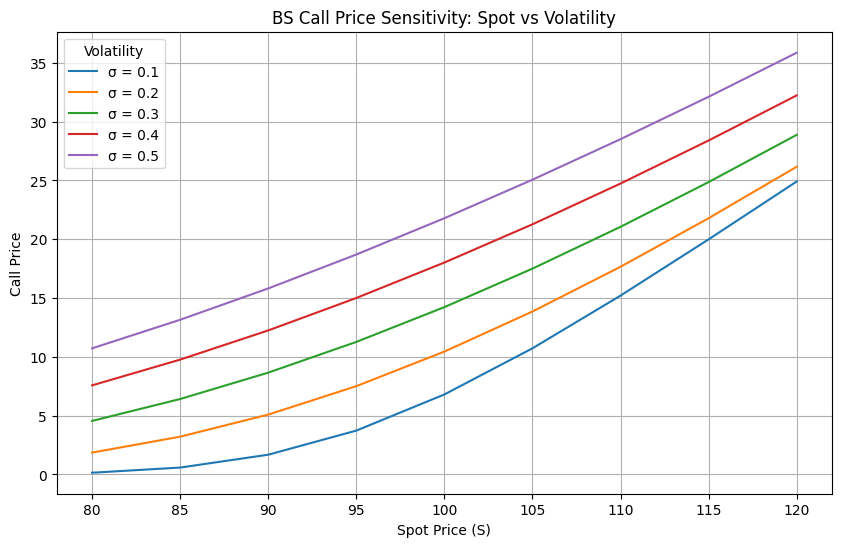

In [ ]:
plt.figure(figsize=(10, 6))

for col in df.columns:
    plt.plot(df.index, df[col], label=f'σ = {col}')

plt.xlabel('Spot Price (S)')
plt.ylabel('Call Price')
plt.title('BS Call Price Sensitivity: Spot vs Volatility')
plt.legend(title='Volatility')
plt.grid(True)
plt.show()